In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier, plot_importance

In [56]:
X = pd.read_csv("data/x_train.txt", sep=" ", header=None)
y = pd.read_csv("data/y_train.txt", sep=" ", header=None)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [58]:
w_neg = (0.4888 / (1 - 0.4888)) * ((1 - 0.2) / 0.2)
class_weights = {
    1: 1.0,
    0: w_neg,
}  # because there are 1955 1s and 2045 0s in the training set
# but we want to mimic 20/80 ratio of 1s to 0s in the test set

In [59]:
clf = LogisticRegression(
    penalty="l2",
    solver="saga",
    class_weight=class_weights,
    random_state=1,
    max_iter=5000,
)
clf.fit(X_train, y_train)

LogisticRegression(class_weight={0: 3.8247261345852896, 1: 1.0}, max_iter=5000,
                   random_state=1, solver='saga')

In [60]:
# recall on test set
y_pred = clf.predict(X_test)
recall = recall_score(y_test, y_pred, pos_label=1)
print(f"Recall on test set: {recall:.4f}")

Recall on test set: 0.2270


In [ ]:
def business_scorer(estimator, X_val, y_val):
    proba = estimator.predict_proba(X_val)[:, 1]
    n_val = len(proba)
    top_obs = max(1, int(np.floor(0.2 * n_val)))
    top_indices = np.argsort(proba)[::-1][:top_obs]
    tp = np.sum(y_val[top_indices] == 1)
    k_features = X_val.shape[1]
    feature_cost = 200
    return ((tp / top_obs) * 10000 - feature_cost * k_features), tp, top_obs

In [105]:
def percent_correct_among_top20percent(estimator, X_val, y_val):
    proba = estimator.predict_proba(X_val)[:, 1]
    n_val = len(proba)
    top_obs = int(np.floor(0.2 * n_val))
    top_indices = np.argsort(proba)[::-1][:top_obs]
    tp = np.sum(y_val[top_indices] == 1)
    return tp / top_obs

In [106]:
clf = XGBClassifier(
    eval_metric=percent_correct_among_top20percent,
    random_state=1,
    n_jobs=20,
    n_estimators=10000,
    max_depth=2,
    subsample=0.5,
    scale_pos_weight=1 / w_neg,
    reg_alpha=0.05,
    reg_lambda=0.01,
)
clf.fit(X_train, y_train, verbose=False)
gain = clf.get_booster().get_score(importance_type="gain")
best_idx = np.where(np.array(list(gain.values())) > 1.7)[0]
clf.fit(X_train[:, best_idx], y_train, verbose=False)
y_pred = clf.predict(X_test[:, best_idx])
recall = recall_score(y_test, y_pred, pos_label=1)
print(f"Recall on test set: {recall:.4f}")
results = business_scorer(clf, X_test[:, best_idx], y_test)
print(f"Found {results[1]} true positives out of {results[2]} top_obs.")
print(f"So percent correct among top 20%: {results[1] / results[2]:.4f}")
print(f"Business score: {results[0]}")

Recall on test set: 0.1943
Found 146 true positives out of 200 top_obs.
So percent correct among top 20%: 0.7300
Business score: 7100.0


(array([  2, 200, 315, 383, 462]),)

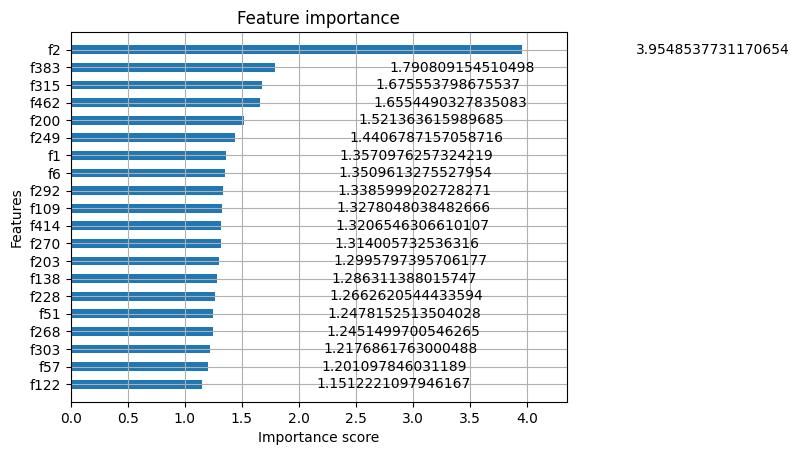

In [ ]:
plot_importance(clf, max_num_features=20, height=0.5, importance_type="gain")


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

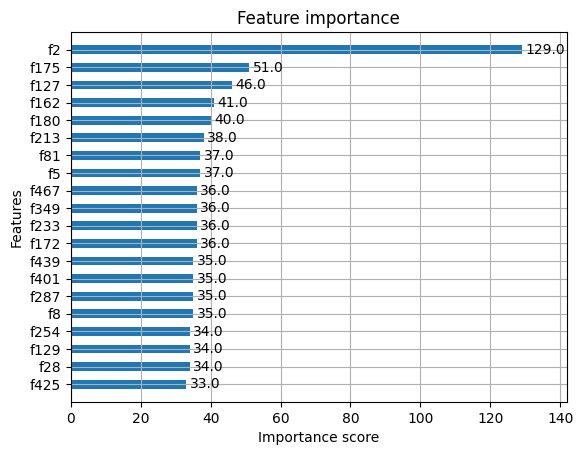

In [ ]:
plot_importance(clf, max_num_features=20, height=0.5)